## Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

sns.set_style("whitegrid")

## Load Dataset

In [8]:
titanic = pd.read_csv("../Session-03/titanic (1).csv")

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Central Tendency of Fare

In [3]:
fare_mean = titanic["Fare"].mean()
fare_median = titanic["Fare"].median()
fare_mode = titanic["Fare"].mode()[0]

print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode)

Mean: 32.204207968574636
Median: 14.4542
Mode: 8.05


## Spread (Standard Deviation)

In [5]:
fare_std = titanic["Fare"].std()
fare_std_by_class = titanic.groupby("Pclass")["Fare"].std()

print("Fare Standard Deviation:")
print(fare_std)

print("\nFare Standard Deviation by Pclass:")
print(fare_std_by_class)

Fare Standard Deviation:
49.6934285971809

Fare Standard Deviation by Pclass:
Pclass
1    78.380373
2    13.417399
3    11.778142
Name: Fare, dtype: float64


## Most Variable Class

In [6]:
print("Most variable fare class:", fare_std_by_class.idxmax())

Most variable fare class: 1


## Five Number Summary of Age

In [7]:
five_number = titanic["Age"].describe()

print(five_number)

q1 = five_number["25%"]
q3 = five_number["75%"]

iqr = q3 - q1

print("\nIQR:", iqr)

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

IQR: 17.875


## IQR Outlier Detection

In [8]:
q1 = titanic["Fare"].quantile(0.25)
q3 = titanic["Fare"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

iqr_outliers = titanic[(titanic["Fare"] < lower) | (titanic["Fare"] > upper)]

print("IQR Outliers:", len(iqr_outliers))

IQR Outliers: 116


## Z-Score Outlier Detection

In [9]:
z_scores = np.abs(zscore(titanic["Fare"]))

z_outliers = titanic[z_scores > 3]

print("Z-Score Outliers:", len(z_outliers))

Z-Score Outliers: 20


## Compare Methods

In [10]:
print("IQR detected:", len(iqr_outliers))
print("Z-Score detected:", len(z_outliers))

IQR detected: 116
Z-Score detected: 20


## Histogram of Age

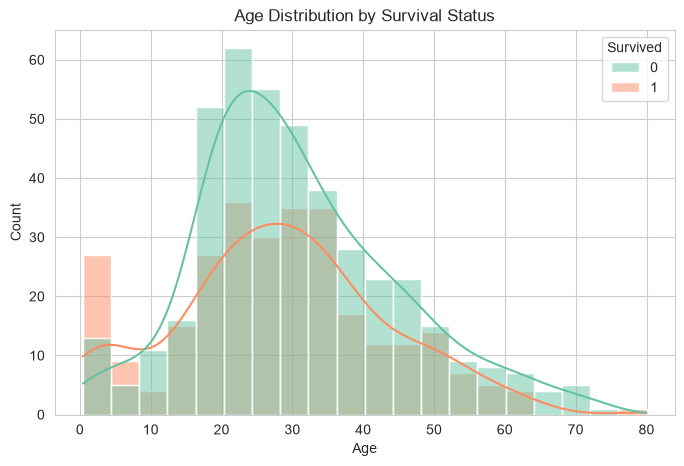

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=titanic,
    x="Age",
    hue="Survived",
    kde=True,
    palette="Set2"
)

plt.title("Age Distribution by Survival Status")

plt.show()

## Histogram of Fare

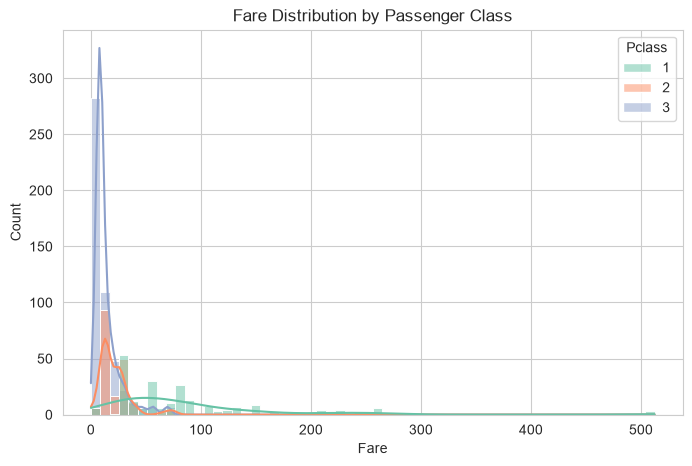

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=titanic,
    x="Fare",
    hue="Pclass",
    kde=True,
    palette="Set2"
)

plt.title("Fare Distribution by Passenger Class")

plt.show()

## Dashboard (2×2)

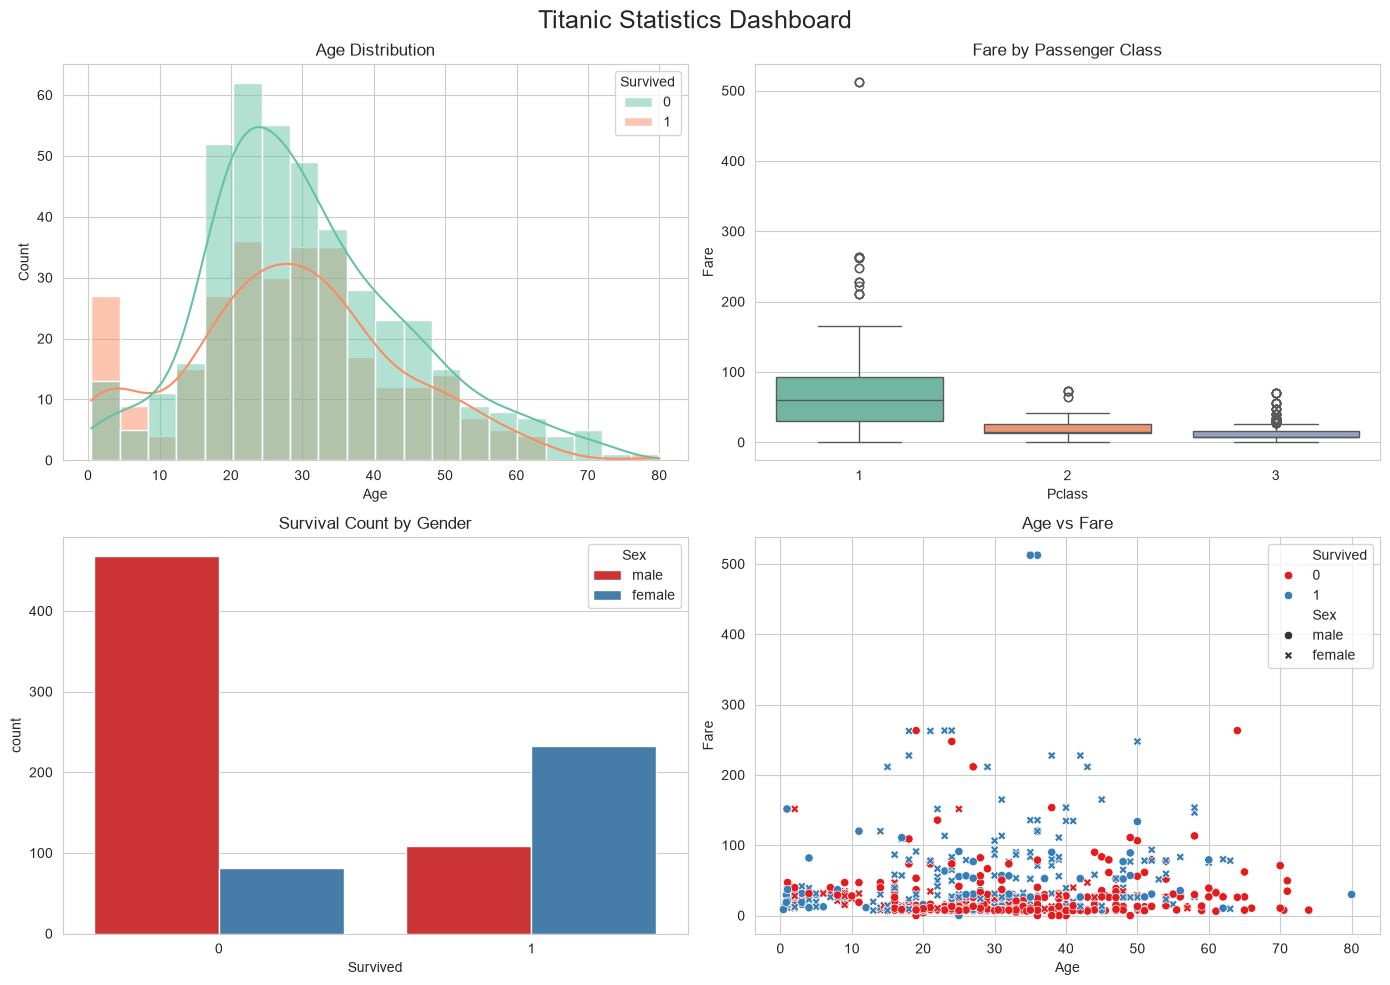

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(
    data=titanic,
    x="Age",
    hue="Survived",
    kde=True,
    palette="Set2",
    ax=axes[0,0]
)
axes[0,0].set_title("Age Distribution")

sns.boxplot(
    data=titanic,
    x="Pclass",
    y="Fare",
    hue="Pclass",
    palette="Set2",
    legend=False,
    ax=axes[0,1]
)
axes[0,1].set_title("Fare by Passenger Class")

sns.countplot(
    data=titanic,
    x="Survived",
    hue="Sex",
    palette="Set1",
    ax=axes[1,0]
)
axes[1,0].set_title("Survival Count by Gender")

sns.scatterplot(
    data=titanic,
    x="Age",
    y="Fare",
    hue="Survived",
    style="Sex",
    palette="Set1",
    ax=axes[1,1]
)
axes[1,1].set_title("Age vs Fare")

fig.suptitle("Titanic Statistics Dashboard", fontsize=18)

plt.tight_layout()

plt.show()